## 1. Importar Bibliotecas Necessárias

In [15]:
import pandas as pd
import numpy as np

## 2. Definir o Caminho do Arquivo CSV

In [16]:
caminho_csv = 'emails.csv'

## 3. Ler o Arquivo CSV em um DataFrame

In [17]:
df = pd.read_csv(caminho_csv)

## 4. Adicionando coluna 'categoria' com valores aleatórios

In [18]:
categorias = ['RH', 'financeiro', 'suporte', 'comercial']
df['categoria'] = np.random.choice(categorias, size=len(df))

## 5. Exibir Informações Gerais do DataFrame

In [19]:
print(f'Shape: {df.shape}')
print(f'\nTipos de dados:\n{df.dtypes}')
print(f'\nInformações gerais:')
df.info()

Shape: (517401, 3)

Tipos de dados:
file         object
message      object
categoria    object
dtype: object

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517401 entries, 0 to 517400
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   file       517401 non-null  object
 1   message    517401 non-null  object
 2   categoria  517401 non-null  object
dtypes: object(3)
memory usage: 11.8+ MB


## 5. Visualizar os Dados do DataFrame

In [20]:
df.head()

,file,message,categoria
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...,comercial
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...,financeiro
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...,suporte
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...,RH
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...,comercial


## 6. Gráfico: Quantidade de E-mails por Categoria

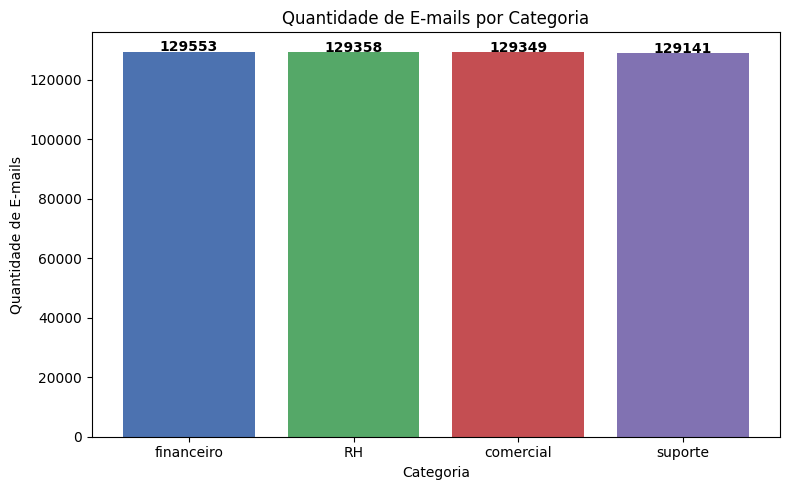

In [21]:
import matplotlib.pyplot as plt

contagem = df['categoria'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(contagem.index, contagem.values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.xlabel('Categoria')
plt.ylabel('Quantidade de E-mails')
plt.title('Quantidade de E-mails por Categoria')
for i, v in enumerate(contagem.values):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Sprint 2 - Treino do Modelo Naive Bayes

Treinamento de um modelo **Naive Bayes** para classificação dos e-mails nas categorias: RH, financeiro, suporte e comercial.

- Divisão dos dados: **70% treino / 30% teste**
- Rastreamento do experimento com **MLflow**

## 7. Importar Bibliotecas para o Treino

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import mlflow
import mlflow.sklearn

## 8. Preparar os Dados e Dividir 70/30

In [23]:
# Separar features (X) e target (y)
X = df['message']
y = df['categoria']

# Dividir em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Dados de treino: {X_train.shape[0]} amostras')
print(f'Dados de teste:  {X_test.shape[0]} amostras')

Dados de treino: 362180 amostras
Dados de teste:  155221 amostras


## 9. Vetorizar o Texto com TF-IDF

In [24]:
# Vetorização TF-IDF para transformar texto em features numéricas
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f'Dimensão do vetor TF-IDF: {X_train_tfidf.shape}')

Dimensão do vetor TF-IDF: (362180, 5000)


## 10. Treinar o Modelo Naive Bayes com MLflow

In [ ]:
import joblib

# Configurar o experimento MLflow
mlflow.set_experiment('classificacao_emails_naive_bayes')

with mlflow.start_run(run_name='naive_bayes_tfidf'):
    # Treinar o modelo Naive Bayes
    modelo = MultinomialNB()
    modelo.fit(X_train_tfidf, y_train)

    # Predições
    y_pred = modelo.predict(X_test_tfidf)

    # Métricas
    acuracia = accuracy_score(y_test, y_pred)
    relatorio = classification_report(y_test, y_pred)

    # Logar parâmetros e métricas no MLflow
    mlflow.log_param('modelo', 'MultinomialNB')
    mlflow.log_param('vetorizacao', 'TF-IDF')
    mlflow.log_param('max_features', 5000)
    mlflow.log_param('test_size', 0.3)
    mlflow.log_param('random_state', 42)
    mlflow.log_metric('acuracia', acuracia)

    # Logar o modelo
    mlflow.sklearn.log_model(modelo, 'modelo_naive_bayes')


    # Salvar e logar o vetorizador TF-IDF como artefato

    joblib.dump(tfidf, 'tfidf_vectorizer.pkl')    
    print(f'Acurácia: {acuracia:.4f}')

    mlflow.log_artifact('tfidf_vectorizer.pkl')

2026/04/02 20:00:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
c:\Users\4960041101\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


Acurácia: 0.2499


In [26]:
# Listar runs do experimento
experimento = mlflow.get_experiment_by_name('classificacao_emails_naive_bayes')
runs = mlflow.search_runs(experiment_ids=[experimento.experiment_id])
runs[['run_id', 'params.modelo', 'params.test_size', 'metrics.acuracia', 'start_time']]

,run_id,params.modelo,params.test_size,metrics.acuracia,start_time
0,3e61dc7382a7433dbea01d25d27b040f,MultinomialNB,0.3,0.249940,2026-04-02 23:00:00.705000+00:00
1,3a3725138a4f4cc4ae811b65c36c0149,None,None,NaN,2026-04-02 22:54:14.177000+00:00
2,d01c5a9c2693441f84a9ea275dd6c801,MultinomialNB,0.3,0.248781,2026-03-28 21:08:08.825000+00:00


# Sprint 3 - Predição de Novos E-mails

Simulação de entrada de novos e-mails (sem categoria), carregando o modelo treinado via **MLflow** e realizando a predição das categorias.

## 12. Carregar os E-mails sem Categoria (simulando entrada)

In [27]:
df_novos = pd.read_csv('emails.csv')
df_novos = df_novos.dropna(subset=['message'])

print(f'E-mails carregados: {df_novos.shape[0]}')
print(f'Colunas: {list(df_novos.columns)}')
df_novos.head()

E-mails carregados: 517401
Colunas: ['file', 'message']


,file,message
0,allen-p/_sent_mail/1.,Message-ID: <18782981.1075855378110.JavaMail.e...
1,allen-p/_sent_mail/10.,Message-ID: <15464986.1075855378456.JavaMail.e...
2,allen-p/_sent_mail/100.,Message-ID: <24216240.1075855687451.JavaMail.e...
3,allen-p/_sent_mail/1000.,Message-ID: <13505866.1075863688222.JavaMail.e...
4,allen-p/_sent_mail/1001.,Message-ID: <30922949.1075863688243.JavaMail.e...


## 13. Carregar o Modelo Treinado do MLflow

In [28]:
# Buscar o último run do experimento
experimento = mlflow.get_experiment_by_name('classificacao_emails_naive_bayes')
runs = mlflow.search_runs(experiment_ids=[experimento.experiment_id], order_by=['start_time DESC'])
ultimo_run_id = runs.iloc[0]['run_id']

# Carregar o modelo do MLflow
modelo_carregado = mlflow.sklearn.load_model(f'runs:/{ultimo_run_id}/modelo_naive_bayes')

print(f'Modelo carregado do run: {ultimo_run_id}')
print(f'Acurácia registrada: {runs.iloc[0]["metrics.acuracia"]:.4f}')

Modelo carregado do run: 3e61dc7382a7433dbea01d25d27b040f
Acurácia registrada: 0.2499


## 14. Vetorizar e Realizar a Predição

In [ ]:
import joblib

# Carregar o vetorizador TF-IDF salvo no MLflow
artefato_path = mlflow.artifacts.download_artifacts(run_id=ultimo_run_id, artifact_path='tfidf_vectorizer.pkl')
tfidf_carregado = joblib.load(artefato_path)

# Vetorizar os novos e-mails com o TF-IDF carregado
X_novos_tfidf = tfidf_carregado.transform(df_novos['message'])

# Realiza a predição

df_novos['categoria_predita'] = modelo_carregado.predict(X_novos_tfidf)

## 15. Gráficos de Avaliação das Predições

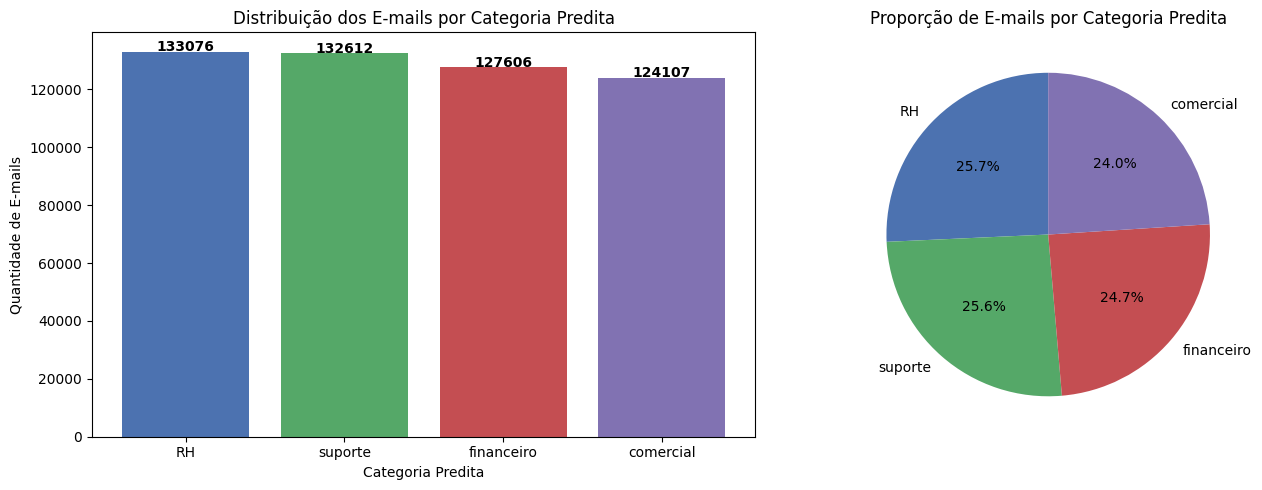

In [31]:
# Gráfico 1 - Distribuição das categorias preditas (barras)
contagem_pred = df_novos['categoria_predita'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

# Gráfico de barras
axes[0].bar(contagem_pred.index, contagem_pred.values, color=cores)
axes[0].set_xlabel('Categoria Predita')
axes[0].set_ylabel('Quantidade de E-mails')
axes[0].set_title('Distribuição dos E-mails por Categoria Predita')
for i, v in enumerate(contagem_pred.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Gráfico de pizza
axes[1].pie(contagem_pred.values, labels=contagem_pred.index, autopct='%1.1f%%',
            colors=cores, startangle=90)
axes[1].set_title('Proporção de E-mails por Categoria Predita')

plt.tight_layout()
plt.show()